In [33]:
import anndata as ad
import scanpy as sc
import numpy as np

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [19]:
DATA_DIR = "/home/ubuntu/data/frangieh"
adata = sc.read_h5ad(f"{DATA_DIR}/rna_qc_filtered.h5ad")

In [ ]:
#Task 1 
#Can a classifier identify which treatment condition a cell came from using its gene expression profile?
#Which genes drive the separation?
#Features are gene expression values, target variable is treatment condition
#Neuronal Network



In [20]:
#we want to work only on hvg
sc.pp.normalize_total(adata)

sc.pp.log1p(adata)

indices = np.arange(adata.n_obs)
labels_full = adata.obs["perturbation_2"].values  

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels_full,
    random_state=42
)


In [21]:
#hvgs on training data
adata_train_only = adata[train_idx].copy()
sc.pp.highly_variable_genes(adata_train_only, n_top_genes=100)
hvg_genes = adata_train_only.var_names[adata_train_only.var["highly_variable"]]

#now contains only hvgs
adata = adata[:, hvg_genes].copy()

In [22]:
#build dataloader
class AnnDataset(Dataset):
    def __init__(self, adata, label_key):
        self.X = adata.X
        self.y = adata.obs[label_key].values

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]

        # Convert sparse row to dense if necessary
        if hasattr(x, "toarray"):
            x = x.toarray().squeeze()

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return x, y

In [23]:
#encodeing of label strings into integers
encoder = LabelEncoder()
adata.obs["perturbation_enc"] = encoder.fit_transform(
    adata.obs["perturbation_2"]
)

In [24]:
dataset_full = AnnDataset(
    adata,
    label_key="perturbation_enc"
)

In [25]:

train_dataset = Subset(dataset_full, train_idx)
val_dataset = Subset(dataset_full, val_idx)

In [26]:
#loaders to subsequently introduce data into the model, controlled using batch_size
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128
)

In [27]:
#build the model
#ReLU as activation function
#using 0.25 as dropout, meaning 25 percent of data is not shown to prevent overfitting
class PerturbationClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

In [28]:
#inititate the model
model = PerturbationClassifier()
#loss function
criterion = nn.CrossEntropyLoss()
#adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


In [29]:
num_epochs = 40 # how often will the model loop the algorithm

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X, y in train_loader: # produces batches (set when the loader was defined 128 cells in the batch 
                                                #100 genes per cell
                                                #128 corresponding perturbation labels)

        optimizer.zero_grad() # So gradients don't accumulate

        outputs = model(X) # Forward pass

        loss = criterion(outputs, y) # Compute loss

        loss.backward() # backpropagation

        optimizer.step() # update weigths

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"loss = {running_loss/len(train_loader):.4f}"
    )
    

Epoch 1: loss = 0.6955
Epoch 2: loss = 0.6463
Epoch 3: loss = 0.6365
Epoch 4: loss = 0.6300
Epoch 5: loss = 0.6272
Epoch 6: loss = 0.6240
Epoch 7: loss = 0.6220
Epoch 8: loss = 0.6202
Epoch 9: loss = 0.6184
Epoch 10: loss = 0.6180
Epoch 11: loss = 0.6164
Epoch 12: loss = 0.6159
Epoch 13: loss = 0.6158
Epoch 14: loss = 0.6150
Epoch 15: loss = 0.6154
Epoch 16: loss = 0.6141
Epoch 17: loss = 0.6125
Epoch 18: loss = 0.6126
Epoch 19: loss = 0.6131
Epoch 20: loss = 0.6116
Epoch 21: loss = 0.6121
Epoch 22: loss = 0.6111
Epoch 23: loss = 0.6114
Epoch 24: loss = 0.6095
Epoch 25: loss = 0.6111
Epoch 26: loss = 0.6102
Epoch 27: loss = 0.6092
Epoch 28: loss = 0.6082
Epoch 29: loss = 0.6093
Epoch 30: loss = 0.6088
Epoch 31: loss = 0.6098
Epoch 32: loss = 0.6094
Epoch 33: loss = 0.6087
Epoch 34: loss = 0.6085
Epoch 35: loss = 0.6089
Epoch 36: loss = 0.6074
Epoch 37: loss = 0.6078
Epoch 38: loss = 0.6078
Epoch 39: loss = 0.6078
Epoch 40: loss = 0.6073


In [30]:
model.eval() # model evaluation

correct = 0
total = 0

with torch.no_grad():
    for X, y in val_loader:
        outputs = model(X)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == y).sum().item()
        total += y.size(0)

accuracy = correct / total

print(f"Validation accuracy: {accuracy:.3f}")


Validation accuracy: 0.734


In [34]:


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in val_loader:
        outputs = model(X)
        predictions = outputs.argmax(dim=1)
        all_preds.extend(predictions.tolist())
        all_labels.extend(y.tolist())

print(classification_report(
    all_labels,
    all_preds,
    target_names=encoder.classes_  
))

              precision    recall  f1-score   support

  Co-culture       0.71      0.83      0.77     14229
     Control       0.67      0.65      0.66     11525
        IFNγ       0.80      0.71      0.75     17020

    accuracy                           0.73     42774
   macro avg       0.73      0.73      0.73     42774
weighted avg       0.74      0.73      0.73     42774



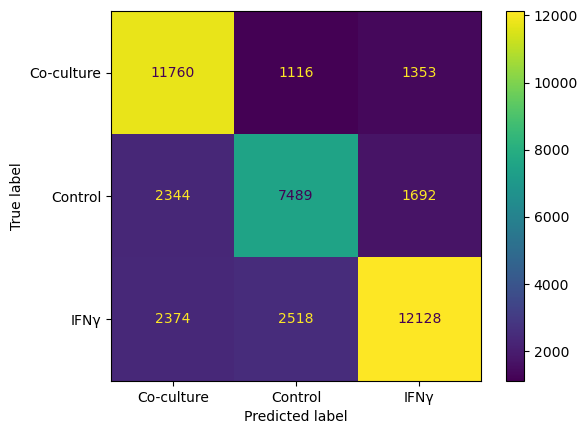

In [35]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=encoder.classes_
)
plt.show()

In [38]:
torch.save(model.state_dict(), f"{DATA_DIR}perturbation_classifier.pt")

## Discussion
### Experimental setup

Data was split using the train_test_split() function of the scikit-learn package, with 80% of the cells used for training and 20% used for validation. The split was stratified on the perturbation label to ensure that all three treatment conditions (Co-culture, Control, IFNγ) are proportionally represented in both sets. As with the random forest approach, model complexity was reduced by restricting the input to the top 100 high-variance genes, computed exclusively on the training split to avoid information leakage into the validation set.

The classifier itself is a fully-connected feed-forward network (PerturbationClassifier) with two hidden layers (100 -> 64 -> 32 -> 3). ReLU activations introduce non-linearity between layers, and a Dropout rate of 0.25 is applied after each hidden layer, meaning 25% of activations are randomly zeroed during each training step to reduce reliance on individual neurons and mitigate overfitting. The model was trained for 40 epochs using the Adam optimizer (lr=1e-3) and CrossEntropyLoss, appropriate for the three-class classification target. Training was performed in batches of 128 cells via a custom AnnDataset/DataLoader pipeline, which converts the (potentially sparse) expression matrix into dense tensors on the fly.

### Model evaluation

The training loss drops quickly within the first few epochs (from 0.696 to around 0.62) and then plateaus, fluctuating narrowly between 0.61 and 0.62 for the remaining epochs. This flattening curve suggests the model converges well before the 40-epoch budget is exhausted, and the absence of a continued downward trend (rather than a sharp drop toward zero) indicates the model is not simply memorizing the training data.

On the held-out validation set, the model reaches an overall accuracy of 73.4%. The per-class metrics reveal that performance is not uniform across conditions: IFNγ is classified most reliably (precision 0.80, recall 0.71), Co-culture shows the highest recall (0.83) but somewhat lower precision (0.71), and Control is the hardest class to separate (precision 0.67, recall 0.65). This pattern suggests that Control cells are most frequently confused with the other two treatment groups, which is biologically plausible given that Co-culture and IFNγ exposure both actively perturb the transcriptome away from a resting baseline, while Control cells may partially overlap with the "less affected" end of both other distributions.

Compared to a tree-based approach, gene expression profiles still carry a clear, learnable signal about treatment condition, but the separation is far from perfect. This is a meaningfully lower ceiling than the near-100% metrics achieved by the random forest classifier, which points to the two models exploiting the expression data differently — the neural network may be more sensitive to the loss of interpretable, per-gene splitting decisions and the regularizing effect of dropout, at the cost of the sharp decision boundaries a tree ensemble can carve out. Unlike the random forest, no feature importance or permutation importance was extracted for this model here, so identifying which of the 100 HVGs drive the network's predictions would require a dedicated follow-up analysis (e.g. integrated gradients or a permutation-based importance approach adapted for PyTorch models).
